# Digital Addiction Detector

## Problem
People waste hours on mobile without realizing, leading to digital addiction and reduced productivity/well-being.

## Goal
Track usage patterns, predict addiction level, and suggest a control plan.

## Approach
1. **Data Generation**: Create synthetic usage data.
2. **Data Analysis**: Explore patterns and correlations.
3. **Regression**: Predict addiction score (0-1000).
4. **Clustering**: Group users into risk levels (Low, Medium, High).
5. **Suggestion Engine**: Provide actionable feedback.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

### 1. Data Generation
We'll generate synthetic data for 500 users.

In [2]:
np.random.seed(42)
n_samples = 500

# Features
daily_screen_time = np.random.uniform(1, 12, n_samples)  # 1 to 12 hours
social_media_usage = daily_screen_time * np.random.uniform(0.3, 0.8, n_samples)
productivity_usage = daily_screen_time * np.random.uniform(0.05, 0.2, n_samples)
sleep_time = 8 - (daily_screen_time * 0.2) + np.random.normal(0, 0.5, n_samples)
sleep_time = np.clip(sleep_time, 3, 10)

# Calculate Addiction Score (Synthetic Target)
# Higher screen time and social media = higher score
# Higher sleep and productivity = lower score
raw_score = (daily_screen_time * 60) + (social_media_usage * 40) - (sleep_time * 30) - (productivity_usage * 20)
addiction_score = (raw_score - raw_score.min()) / (raw_score.max() - raw_score.min()) * 1000

df = pd.DataFrame({
    'daily_screen_time': daily_screen_time,
    'social_media_usage': social_media_usage,
    'productivity_usage': productivity_usage,
    'sleep_time': sleep_time,
    'addiction_score': addiction_score
})

print(df.head())

   daily_screen_time  social_media_usage  productivity_usage  sleep_time  \
0           5.119941            3.323256            0.398178    5.726309   
1          11.457857            6.508615            1.504246    6.853900   
2           9.051933            4.116492            1.637874    5.494827   
3           7.585243            5.361990            1.212378    5.660252   
4           2.716205            1.744797            0.464428    7.968044   

   addiction_score  
0       404.887282  
1       834.071349  
2       642.213852  
3       609.308892  
4       142.725800  


### 2. Data Analysis
Visualizing the relationships between usage and addiction score.

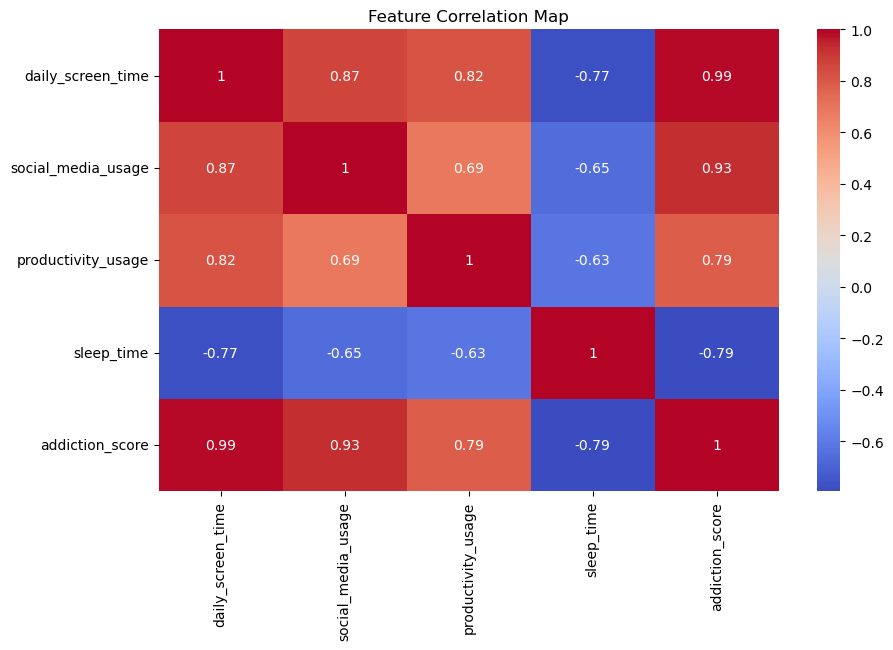

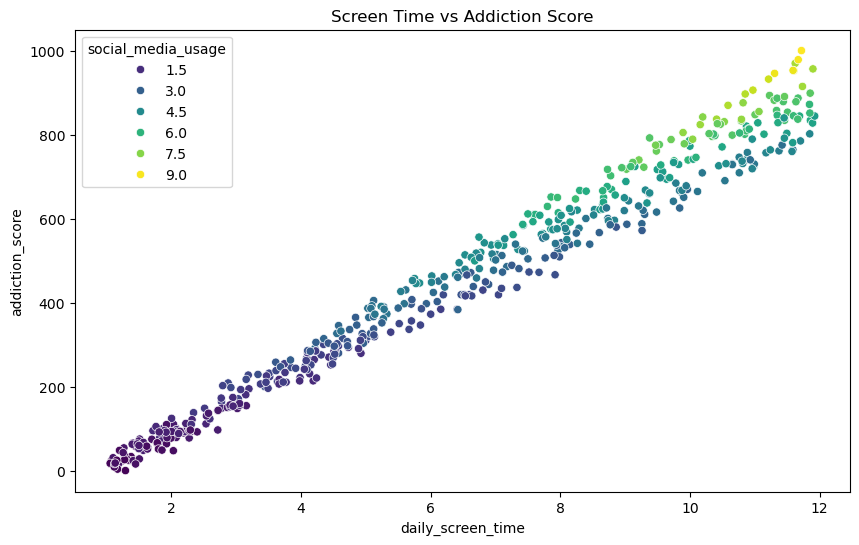

In [3]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Map")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x='daily_screen_time', y='addiction_score', hue='social_media_usage', data=df, palette='viridis')
plt.title("Screen Time vs Addiction Score")
plt.show()

### 3. Regression: Predicting Addiction Score
Using Linear Regression to predict the score based on usage patterns.

In [4]:
X = df[['daily_screen_time', 'social_media_usage', 'productivity_usage', 'sleep_time']]
y = df['addiction_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

y_pred = reg_model.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")

R2 Score: 1.0000
MSE: 0.0000


### 4. Clustering: Risk Level Identification
Using KMeans to group users into Low, Medium, and High risk.

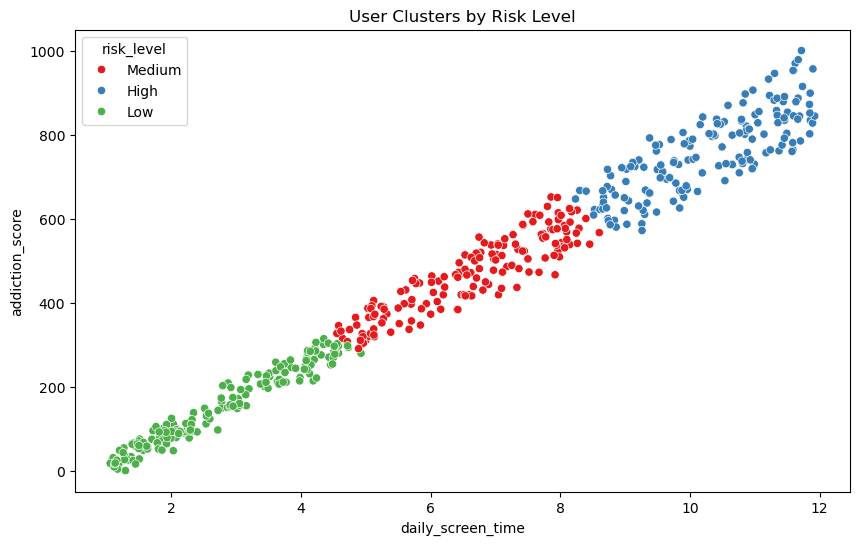

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['daily_screen_time', 'addiction_score']])

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Map clusters to Risk Levels based on average score
cluster_means = df.groupby('cluster')['addiction_score'].mean().sort_values()
risk_mapping = {cluster_means.index[0]: 'Low', cluster_means.index[1]: 'Medium', cluster_means.index[2]: 'High'}
df['risk_level'] = df['cluster'].map(risk_mapping)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='daily_screen_time', y='addiction_score', hue='risk_level', data=df, palette='Set1')
plt.title("User Clusters by Risk Level")
plt.show()

### 5. Suggestion Engine
Function to provide personalized suggestions.

In [6]:
def get_suggestions(user_data):
    score = reg_model.predict([user_data])[0]
    
    if score < 300:
        level = "Low"
        suggestion = "You have a healthy balance. Keep it up!"
    elif score < 700:
        level = "Medium"
        suggestion = f"Reduce Social Media by {user_data[1]*0.2:.1f} hrs and increase sleep."
    else:
        level = "High"
        suggestion = f"Urgent: Limit screen time to 4hrs. Reduce Insta/TikTok by {user_data[1]*0.5:.1f} hrs immediately."
    
    return score, level, suggestion

# Test with a sample user
sample_user = [10.5, 8.0, 0.5, 4.5] # 10.5hrs total, 8hrs social, 0.5 productivity, 4.5hrs sleep
score, risk, advice = get_suggestions(sample_user)

print(f"Addiction Score: {score:.0f}/1000")
print(f"Risk Level: {risk}")
print(f"Suggestion: {advice}")

Addiction Score: 922/1000
Risk Level: High
Suggestion: Urgent: Limit screen time to 4hrs. Reduce Insta/TikTok by 4.0 hrs immediately.
